In [4]:
import pandas as pd
df_train = pd.read_csv('data/df_train_02.csv', index_col=0)
df_test = pd.read_csv('data/df_test_02.csv', index_col=0)

from sklearn import tree

clf = tree.DecisionTreeClassifier(random_state=1234, # 난수 고정
                                  max_depth=3)

train_x = df_train.drop(columns='income') # 예측 변수 추출
train_y = df_train['income'] # 타겟 변수 추출

model = clf.fit(X=train_x, y=train_y) # 모델 만들기

import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize':[12, 8], # 그래프 크기 설정
                     'figure.dpi': '100'}) # 해상도 설정

# 5. 모델을 이용해 예측하기
# 모델을 활용해 새 데이터의 타겟 변수를 예측하는 방법을 알아봄
# 먼저 모델을 만들 때 사용하지 않은 df_test에서 예측 변수와 타겟 변수를 각각 추출

test_x = df_test.drop(columns='income') # 예측 변수 추출
test_y = df_test['income'] # 타겟 변수 추출

# model.predict()를 이용하면 모델을 이용해 새 데이터의 타겟 변수 값을 예측할 수 있음

# 예측값 구하기
df_test = df_test.copy()
df_test['pred'] = model.predict(test_x)
print(df_test)





       Unnamed: 0  age  education_num  capital_gain  capital_loss  \
11712       11712   58             10             0             0   
24768       24768   39             10             0             0   
26758       26758   31              4             0             0   
14295       14295   23              9             0             0   
3683         3683   24              9             0             0   
...           ...  ...            ...           ...           ...   
11985       11985   24             13             0             0   
48445       48445   35             13         10520             0   
19639       19639   41              9             0             0   
21606       21606   29              4             0             0   
3822         3822   31             13             0             0   

       hours_per_week  workclass_?  workclass_Federal-gov  \
11712              60        False                  False   
24768              40        False               

In [5]:
# model.predict()에 test_x를 입력해 타겟 변수 예측값을 구한 다음 df_test['pred']에 할당
# df_test를 출력하면 가장 오른쪽에 pred가 만들어진 것을 확인
# pred는 모델이 train_x에 들어 있는 예측 변수만 이용해서 구한 값
# income과 pred의 값을 보면 모델의 예측이 맞는지 알 수 있음
# 두 변수의 값이 같으면 예측이 맞는 것이고, 두 변수의 값이 다르면 예측이 틀린 것

print(df_test['pred'])

11712     low
24768     low
26758     low
14295     low
3683      low
         ... 
11985     low
48445    high
19639     low
21606     low
3822      low
Name: pred, Length: 14653, dtype: str


In [7]:
# 6. 성능 평가하기
# 예측값을 실제값과 대조해 예측이 얼마나 잘 맞았는지 모델의 성능을 평가
# 성능 평가 지표는 종류가 다양하고 특징이 서로 달라서 어떤 지표가 높더라도
# 다른 지표는 낮을 수 있음
# 그러므로 모델을 사용하는 목적에 맞게 평가 기준으로 삼을 지표를 선택해야함

# 01. confusion matrix 만들기
# 컨퓨젼 매트릭스(confusion matrix, 혼동 행렬): 모델이 예측한 값 중 맞는 경우와 틀린 경우의 빈도
# sklearn.metrics의 confusion_matrix()을 이용해서 컨퓨전 매트릭스를 만듬

# confusion_matrix()의 파라미터
# y_true : 타겟 변수
# y_pred : 예측 변수
# labels: 클래스 배치 순서

from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_true=df_test['income'], # 실제값
                            y_pred=df_test['pred'], # 예측값
                            labels=['high', 'low']) # 클래스 배치 순서
print(conf_mat)

[[ 1801  1705]
 [  582 10565]]


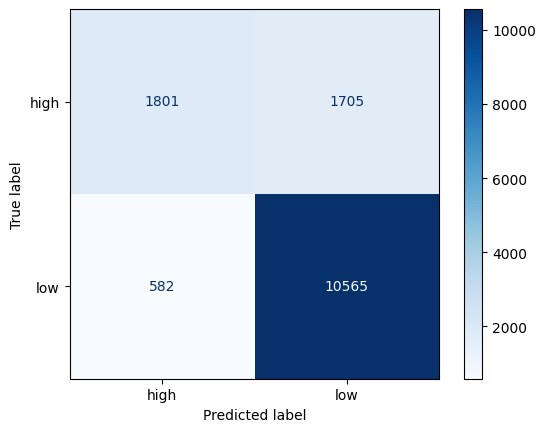

In [9]:
# sklearn.metrics의 ConfusionMatrixDisplay()를 이용해 컨퓨전 매트릭스로 히트맵 heatmap을 만들어 값을 살펴봄
# 히트맵은 격자 위에 값을 표시하고 값이 클수록 셀의 색농도를 진하게 표현한 그래프

plt.rcParams.update(plt.rcParamsDefault)
from sklearn.metrics import ConfusionMatrixDisplay

p = ConfusionMatrixDisplay(confusion_matrix=conf_mat,
                           display_labels=['high', 'low']) # 타겟 변수 클래스명
p.plot(cmap='Blues')
plt.show()


In [11]:
# 02. confusion matrix 해석하기
# 컨퓨전 매트릭스의 행은 실제 True 빈도를 의미
# 첫 번째 행은 income이 실제로 high인 사람, 두 번째 행은 실제로 low인 사람을 나타램

# 열은 모델이 예측한 predicted 빈도를 의미
# 첫 번째 열은 모델이 high로 예측한 사람, 두 번째 열은 low로 예측한 사람

# 컨퓨전 매트릭스를 보면 예측이 맞는 빈도와 틀린 빈도를 알 수 있음
# 행과 열의 레이블 label이 같은 왼쪽 대각선의 두 셀은 예측이 맞는 빈도
# 반대로 레이블이 서로 다른 오른쪽 대각선의 두 셀은 예측이 틀린 빈도

# 첫 번째 열의 값
# 모델이 2383명 (1801+582)을 high 예측
# 이 중 실제로 high인 사람은 1801명 (정답)
# 이 중 실제로 low인 사람은 582명 (오답)

# 두번째 열의 값
# 모델이 12270명(1705+10565)을 low로 예측
# 이 중 실제로 low인 사람은 10565명 (정답)
# 이 중 실제로 high인 사람은 1705명 (오답)

# 03. 컨퓨진 매트릭스의 셀 이름
# True Positive (TP) : False Negative (FN)
# False Positive (FP) : Ture Negative (TN)

# 컨퓨전 매트릭스의 각 셀은 다음과 같은 단어로 표현
# * 정답 여부 (True / False) : 모델의 예측값이 실제 값과 일치하면 True, 일치하지 않으면 False
# * 예측 클래스 (Positive / Negative) : 타겟 변수의 클래스 중 모델이 예측하고자 하는 관심 클래스는 Positive,
# 그 반대는 Negative
# 여기서 모델의 목적이 고소득자를 찾아내는 것이므로 income이 high인 Positive, low면 Negative가 됨
# 컨퓨전 매트릭스의 셀 이름은 True / False와 Positive / Negative의 첫 글자를 따서 TP, TN, FP, FN으로 줄여서 표현


# 1) Accuracy
# Accuracy(정확도)는 모델이 '예측해서 맞춘 비율'을 의미
# 컨퓨전 매트릭스 전체 셀 합계에서 왼쪽 대각선 셀의 합계가 차지하는 비율이 accuracy
# 모델의 성능을 평가할 때 기본적으로 accuracy을 가장 먼저 구함

# accuracy는 앞에서 만든 conf_mat을 이용해 직접 계산할 수도 있지만
# sklearn.metrics의 accuracy)score()을 이용하면 구할 수 있음

import sklearn.metrics as metrics
accuracy = metrics.accuracy_score(y_true=df_test['income'], # 실제값
                                  y_pred=df_test['pred']) # 예측값

print(accuracy)

score = model.score(test_x, test_y)
print(score)
# 출력 결과를 보면 accuracy가 약 84.3% 하는 것을 알 수 있음

# accuracy는 타겟 변수의 클래스별 비율이 불균형하면 신뢰하기 어렵다는 제한점이 있음
# adult 데이터는 연소득이 low에 해당하는 사람이 76%로 매우 많음
# 어떤 데이터를 입력하든 항상 low로 예측하는 이상한 모델을 만들더라도 accuracy는 최소 76%가 됨
# 따라서 accuracy만 봐서는 점수가 높더라도 모델의 성능이 좋아서인지 아니면
# 자료가 불균형해서인지 판단이 어려움

0.8439227461953184
0.8439227461953184


In [13]:
# 2) Precision
# precision 정밀도는 모델이 '관심 클래스를 예측하여 맞춘 비율'
# 고소득자 예측 모델에서는 모델이 income을 high로 예측한 사람 중에서 실제로 high인 사람의 비율
# 다른 예로 당뇨병 예측 모델이라면 모델이 발병으로 예측한 사람 중에서 실제로 발생한 사람의 비율
# 컨퓨전 매트릭스 첫 번째 열의 셀의 합계에서 위쪽 셀이 차지하는 비율을 구하면 precision 됨

# metrics.precision.score()을 이용하면 precision을 구할 수 있음

precision = metrics.precision_score(y_true=df_test['income'],
                                    y_pred=df_test['pred'],
                                    pos_label='low') # 관심 클래스
print(precision)

# 출력 결과를 보면 모델의 precision 75.5%
# 따라서 모델이 income을 high로 예측한 사람 중 75.5%가 실제로 high이고,
# 나머지 24.5%는 실제로 low인데 high로 잘못 분류한 것

0.8610431947840261


In [14]:
# 3) Recall
# recall 재현율은 모델이 '실제 데이터에서 관심 클래스를 찾아낸 비율'
# 고소득자 예측 모델에서는 income이 실제로 high인 사람 중에서 모델이 high로 예측해서 찾아낸 사람의 비율
# 다른 예로 당뇨병 예측 모델이라면 모델이 발병으로 예측해서 찾아낸 비율
# 컨퓨전 매트릭스 첫 번째 열의 셀의 합계에서 왼쪽 셀이 차지하는 비율

# metrics.recall_score()을 이용하면 recall을 구할 수 있음

recall = metrics.recall_score(y_true=df_test['income'],
                              y_pred=df_test['pred'],
                              pos_label='high')
print(recall)

# 출력 결과를 보면 모델의 recall이 51.3%




0.5136908157444381


In [15]:
# 4) F1 score
# recall과 precision이 모두 중요할 때는 recall과 precision의 크기를 함께 반영한 F1 score을 사용
# F1 score는 recall과 precision의 조화평균으로 0 ~ 1 사이의 값을 지니며
# 성능이 높을수록 1에 가까운 값
# recall과 precision을 곱해서 구하기 때문에 둘 중 하나라도 0이면 0이 됨

# F1 score는 accuracy와 달리 타겟 변수의 클래스가 불균형해도 모델의 성능을 잘 표현
# 예를 들어 Negative 클래스가 훨씬 많은 불균형 데이터를 예측할 때
# 어떤 모델은 데이터를 대부분 Negative로만 예측하고 Positive로는 거의 예측하지 않을 수 있음
# 어떤 모델은 Positive 클래스를 거의 맞추지 못해 recall과 precision이 낮은데도 accuracy를 구하면 매우 높게 나옴
# 반면 F1 score는 recall과 precision의 조화 평균이기 때문에 매우 낮게 나옴

# F1 score는 recall과 precision을 고루 반영하고 클래스가 불균형해도 모델의 성능을 잘 나타내므로
# 여러 모델의 성능을 한가지 지표로 비교해야 할 때 특히 자주 사용

# metrics.f1_score()를 이용하면 F1 score를 구할 수 있음
f1_score = metrics.f1_score(y_true=df_test['income'],
                            y_pred=df_test['pred'],
                            pos_label='high')

print(f1_score)
# 출력 결과를 보면 F1 score가 0.61


0.6116488368143997


In [16]:
# 3) 어떤 성능 평가 지표를 사용해야 할까?
# 성능 평가 지표는 특징이 서로 달라서 어떤 지표가 높더라도 다른 지표는 낮을 수 있음
# 모델을 사용하는 목적에 맞게 평가 기준으로 삼을 지표를 선택해야 함
# accuracy는 모델의 일반적인 성능을 나타내므로 항상 살펴봐야 하고,
# 이에 대해 목적에 따라 precision 또는 recall 중 한 가지 이상을 함께 살펴봐야함

# a) precision : 관심 클래스가 분명할 경우
# 모델을 사용하는 목적이 타겟 변수의 클래스 중에서 관심을 두는 한쪽 클래스를 정확하게 예측하는 것이라면
# precision 기준으로 평가
# 예를 들어 고소득자를 예측해 고가의 제품을 홍보한다면 모델이 고소득자로 예측했을 때 얼마나 잘 맞는지 살펴봐야 하므로
# precision을 기준으로 평가해야 함
# 이처럼 타겟 변수의 한쪽 클래스에 분명한 관심이 있을 때 precision을 사용

# b) recall : 관심 클래스를 최대한 많이 찾아내야 할 경우
# 모델을 사용하는 목적이 관심 클래스를 최대한 많이 찾아내는 것이라면 recall 기준으로 성능을 평가
# 예를 들어 전염병에 감염된 사람을 최대한 많이 찾아내 격리해야 한다면, 실제로 전염병에 감염된 사람 중에서
# 몇 퍼센트 감염된 것으로 예측하는지 살펴봐야 하므로 recall을 기준으로 평가

# c) 관심 클래스로 예측해서 틀릴 때 손실 vs 관심 클래스를 놓칠 때 손실
# 평가 기준으로 삼을 지표를 결정하는 또 다른 방범은 데이터를 '관심 클래스로 예측해서 틀릴 때' 손실과
# '관심 클래스를 놓칠 때'의 손실 중 무엇이 더 큰지를 놓고 판단하는 것
# 데이터를 관심 클래스로 예측해서 틀릴 때 손실이 더 크면 precision
# 반대로 관심 클래스를 놓칠 때 손실이 더 크면 recall을 평가 기준으로 사용

# * 예시 1) 고소득자에게 값비싼 선물을 보내 구매를 독려하는 마케팅 활동
# 관심 클래스로 예측해서 틀릴 때의 손실 : 구매할 가능성이 낮은 저소득자에게 값 비싼 선물을 보냄
# 관심 클래스를 놓칠 때 손실: 구매할 가능성이 있는 고소득자에게 선물을 보내지 않음

# 이 때는 데이터를 관심 클래스로 예측해서 틀릴 때의 손실이 더 큼
# 따라서 비관심 클래스 negative를 관심 클래스 positive로 예측하는 오류 false positive를 줄여야 하므로
# precision 기준으로 모델을 평가해야 함

# 예시 2) 전염병에 걸린 사람을 찾아 격리하는 방역 활동
# 관심 클래스로 예측해서 틀릴 때의 손실 : 정상인을 확진자로 분류해서 불필요하게 격리함
# 관심 클래스를 놓칠 때의 손실: 확진자를 격리하지 않아서 전염병이 확산됨

# 이때는 관심 클래스를 놓칠 때의 손실이 더 큼
# 따라서 관심클래스를 비관심 클래스로 예측하는 오류 false positive를 줄여야 하므로 recall 기준으로 모델을 평가해야 함


# d) f1 score : recall 과 precision이 모두 중요할 때
# 데이터를 관심 클래스로 예측해서 틀릴 대의 손실과 관심 클래스를 놓칠 때의 손실이 둘 다 중요하다면
# recall과 precision을 모두 판단 기준으로 삼아야 함
# 그런데 여러 모델을 만들어 성능을 비교할 때 평가 기준 지표가 여러 개의 지표에 따라 성능이 좋다고
# 판단되는 모델이 다를 수 있음
# 이럴 때는 F1 score를 평가 기준으로 삼으면 됨
# F1 score를 이용하면 여러 모델 중에 어떤 모델이 우수한지 한 가지 기준으로 비교할 수 있음

# 6) 모델의 성능 지표가 얼마면 될까?
# 모델의 성능 지표는 얼마를 넘겨야 모델을 사용할 수 있다는 절대적인 기준이 없음
# 모델이 쓸만한지는 기존에 해오던 방식으로 예측했을 때의 모델을 이용해 예측했을 때의 성능 지표를 비교해야 판단할 수 있음

# 예를 들어 모델의 accuracy가 60%밖에 안된다 하더라도 기존 방식으로 사람이 직접 예측했을 때 accuracy가 55%라면
# 모델을 사용하는 게 낫다고 판단될 수 있음
# 반대로 모델의 accuracy가 95%로 높더라도 기존 방식의 accuracy가 96%라면 기존 방식을 유지하는게 낫다고 판단

# 예측 방식을 선택할 때는 예측에 드는 시간과 비용도 고려해야 함
# 예측 성능이 아무리 좋더라도 예측하는데 시간이 오래 걸리고 비용이 많이 든다면 사용하기 어려움
# 따라서 모델을 이용해 예측할 때와 기존 방식으로 예측할 때 드는 시간과 비용을 비교해 모델을 사용할지 여부를 결정해야 함

